# MNIST: CNN Accuracy vs Computational Cost (PyTorch)

This notebook compares a dense neural network and three CNN architectures on MNIST. Students will measure accuracy, parameter counts, model size, and training time to understand the tradeoff between model complexity and performance.

In [1]:
# requirements
%pip install torch torchvision pandas matplotlib

  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/124.1 MB 5.2 MB/s eta 0:00:24
    --------------------------------------- 1.6/124.1 MB 4.6 MB/s eta 0:00:27
    --------------------------------------- 2.4/124.1 MB 4.3 MB/s eta 0:00:29
   - -------------------------------------- 3.1/124.1 MB 4.5 MB/s eta 0:00:28
   - -------------------------------------- 4.2/124.1 MB 4.4 MB/s eta 0:00:28
   - -------------------------------------- 5.2/124.1 MB 4.5 MB/s eta 0:00:27
   -- ------------------------------------- 6.3/124.1 MB 4.6 MB/s eta 0:00:26
   -- ------------------------------------- 7.1/124.1 MB 4.6 MB/s eta 0:00:26
   -- ------------------------------------- 7.9/1

In [2]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)

PyTorch: 2.14.1+cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset,batch_size=128,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=128,shuffle=False)

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")
print("Device:", device)

100.0%
100.0%
100.0%
100.0%


Device: cpu


In [4]:
class DenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.layers(x)

In [5]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1,8,3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(8*13*13,10)
        )

    def forward(self,x):
        return self.network(x)

In [6]:
class MediumCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,16,3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*5*5,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.classifier(self.features(x))

In [7]:
class LargeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.classifier(self.features(x))

In [8]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_and_evaluate(model, epochs=3):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start = time.time()

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    train_time = time.time() - start

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            predictions = model(images).argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total

    return accuracy, train_time

In [9]:
models = {
    "Dense": DenseNet(),
    "Small CNN": SmallCNN(),
    "Medium CNN": MediumCNN(),
    "Large CNN": LargeCNN()
}

results = []

for name, model in models.items():

    print(f"Training {name}")

    accuracy, train_time = train_and_evaluate(model, epochs=3)

    params = count_params(model)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Parameters": params,
        "Model Size (MB)": params * 4 / (1024**2),
        "Train Time (s)": train_time
    })

df = pd.DataFrame(results)
df.sort_values("Accuracy", ascending=False)

Training Dense
Training Small CNN
Training Medium CNN
Training Large CNN


,Model,Accuracy,Parameters,Model Size (MB),Train Time (s)
3,Large CNN,0.9889,467818,1.784584,251.762427
2,Medium CNN,0.9835,56714,0.216347,60.848131
1,Small CNN,0.9655,13610,0.051918,103.317521
0,Dense,0.9629,101770,0.388222,76.445527


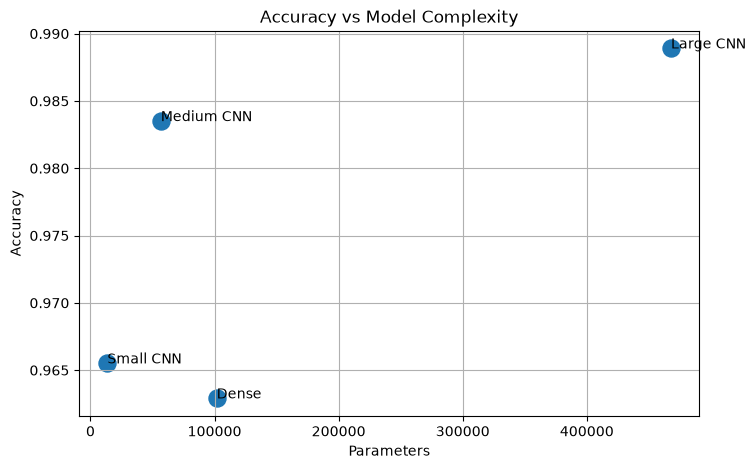

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["Parameters"], df["Accuracy"], s=150)

for _, row in df.iterrows():
    plt.annotate(row["Model"], (row["Parameters"], row["Accuracy"]))

plt.xlabel("Parameters")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Complexity")
plt.grid(True)
plt.show()

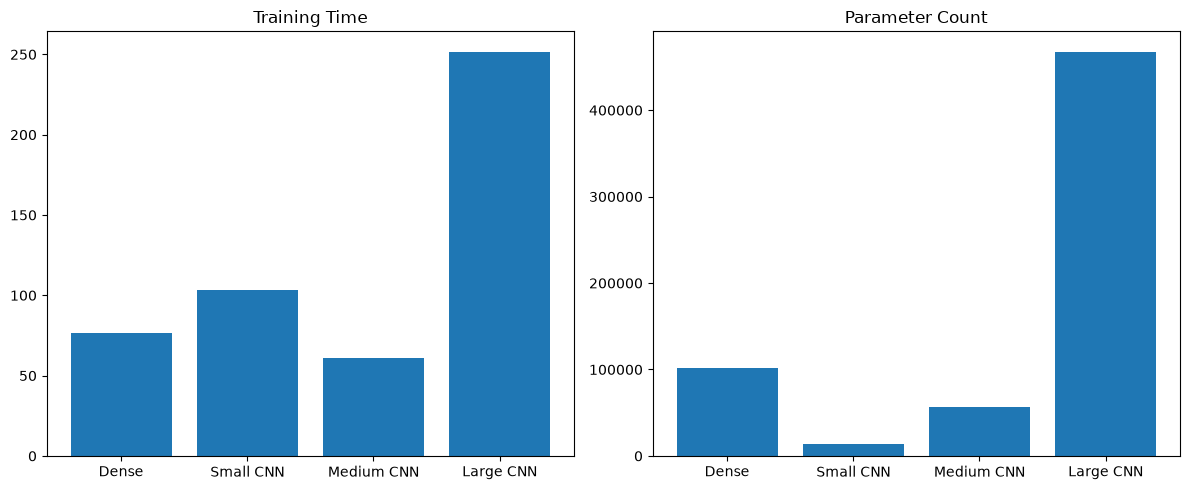

In [11]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].bar(df["Model"], df["Train Time (s)"])
ax[0].set_title("Training Time")

ax[1].bar(df["Model"], df["Parameters"])
ax[1].set_title("Parameter Count")

plt.tight_layout()
plt.show()

## Optional FLOP and Memory Analysis
Install torchinfo and inspect a model.

In [12]:
%pip install torchinfo
from torchinfo import summary
summary(LargeCNN(), input_size=(1,1,28,28))

Note: you may need to restart the kernel to use updated packages.


Layer (type:depth-idx)                   Output Shape              Param #
LargeCNN                                 [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─ReLU: 2-2                         [1, 32, 28, 28]           --
│    └─Conv2d: 2-3                       [1, 32, 28, 28]           9,248
│    └─ReLU: 2-4                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-5                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-6                       [1, 64, 14, 14]           18,496
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─Conv2d: 2-8                       [1, 64, 14, 14]           36,928
│    └─ReLU: 2-9                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-10                   [1, 64, 7, 7]             --
├─Sequential: 1-2                        [1, 10]                   --
│  

## Discussion Questions
1. Why do CNNs outperform dense networks on images?
2. Which model has the best accuracy-per-parameter ratio?
3. At what point do larger models provide diminishing returns?
4. Which model would be most appropriate for mobile deployment?
5. How do parameter count and training time relate to accuracy?